# 3B - Planung von CO2 Transportnetz

Im folgenden Skript wurde die Aufgabenstellung der Planung eines CO2-Transportnetzes erstellt. Das Netz besteht aus einer Quelle und zwei Senken, einer On-shore, einer Off-shore. Diese weisen unterschiedliche von uns angenommene Parameter auf.
Weiters wurden einige Vereinfachung getroffen. Unser CO2 Netz speichert beispielsweise kein CO2, außerdem wurden nur die variablen Kosten betrachtet. 


In [42]:
#Skizze der Aufgabenstellung:

#               Quelle
#                  |
#          ----------------
#          |              |
#    Senke on-shore   Senke off-shore

In [43]:
from pyomo.environ import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns

#Data
T = 6
timesteps = np.arange(T)

startfüllstand1 = 0 # tCO2
startfüllstand2 = 0 # tCO2
minfüllstand1 = 0 # tCO2
minfüllstand2 = 0 # tCO2
maxfüllstand1 = 100000000 # tCO2
maxfüllstand2 = 300000000 # tCO2

q_CO2 = [20000000,30000000,50000000,60000000,90000000,30000000] #tCO2
c1_opex = 50 # €/tCO2
c2_opex = 90 # €/tCO2
max_cap_pipe1 = 20000000 #tCO2/y
max_cap_pipe2 = 100000000 #tCO2/y


In [44]:
# Pyomo Modell aufstellen
model = ConcreteModel()

# Sets definieren
model.time = Set(initialize = timesteps)

# Parameter definieren
model.c1_opex= Param(model.time, initialize = c1_opex) # Opex Senke 1
model.c2_opex= Param(model.time, initialize = c2_opex) # Opex Senke 2

# Variablen definieren
model.x1 = Var(model.time, within= NonNegativeReals) # Menge_Senke 1
model.x2 = Var(model.time, within= NonNegativeReals) # Menge_Senke 2

model.soc1 = Var(model.time, within = NonNegativeReals) # Speicherfüllstand
model.soc2 = Var(model.time, within = NonNegativeReals) # Speicherfüllstand

# Zielfunktion angeben
model.obj = Objective(
        expr=sum(model.x1[t] * model.c1_opex[t]  + model.x1[t] * model.c1_opex[t] for t in model.time),
        sense=minimize)

# Nebenbedingeungen definieren 
# Speicherbilanz 
def soc_con_rule1(model, t):
    if t == 0:  
        return model.soc1[t] == startfüllstand1
    else:  
        return model.soc1[t] == model.soc1[t-1] + model.x1[t]
model.soc_con1 = Constraint(model.time, rule=soc_con_rule1)

def soc_con_rule2(model, t):
    if t == 0:  
        return model.soc2[t] == startfüllstand2
    else:  
        return model.soc2[t] == model.soc2[t-1] + model.x2[t]
model.soc_con2 = Constraint(model.time, rule=soc_con_rule2)

#Speicher 1
# minimaler Speicherfüllstand
def min_soc_rule1(model, t):
    return model.soc1[t] >= minfüllstand1
model.min_soc_con1 = Constraint(model.time, rule=min_soc_rule1)

# maximaler Speicherfüllstand
def max_soc_rule1(model, t):
    return model.soc1[t] <= maxfüllstand1
model.max_soc_con1 = Constraint(model.time, rule=max_soc_rule1)

# Speicherfüllstand zu Beginn
def start_soc_rule1(model):
    return model.soc1[0] == 0
model.start_soc_con1 = Constraint(rule=start_soc_rule1)

#Speicher 2
# minimaler Speicherfüllstand
def min_soc_rule2(model, t):
    return model.soc2[t] >= minfüllstand2
model.min_soc_con2 = Constraint(model.time, rule=min_soc_rule2)

# maximaler Speicherfüllstand
def max_soc_rule2(model, t):
    return model.soc2[t] <= maxfüllstand2
model.max_soc_con2 = Constraint(model.time, rule=max_soc_rule2)

# Speicherfüllstand zu Beginn
def start_soc_rule2(model):
    return model.soc2[0] == 0
model.start_soc_con2 = Constraint(rule=start_soc_rule2)

# CO2-Bilanz

def q_CO2_rule(model,t):
    return (model.x1[t] + model.x2[t]) == q_CO2[t]
model.q_CO2 = Constraint(model.time, rule = q_CO2_rule)

#Relative Speicherfüllstände
def rel_soc_rule(model):
    return model.soc1[5]/maxfüllstand1 == model.soc2[5]/maxfüllstand2
model.rel_soc_rule = Constraint(rule=rel_soc_rule)

#Technische Kapazitätsgrenzen
def pipe1_cap_rule(model,t):
    return model.x1[t] <= max_cap_pipe1
model.pipe1_cap_rule = Constraint(model.time, rule=pipe1_cap_rule)

def pipe2_cap_rule(model,t):
    return model.x2[t] <= max_cap_pipe2
model.pipe2_cap_rule = Constraint(model.time, rule=pipe2_cap_rule)



In [45]:
solver = SolverFactory('gurobi')
results = solver.solve(model, tee=True)


#Print Entscheidungsvariablenergebnis
print("\nOptimale Werte für x1 und x2:")
for t in model.time:
    print(f"t = {t}:  x1 = {model.x1[t].value:.2f},  x2 = {model.x2[t].value:.2f}")

print("\nSpeicherfüllstände:")
for t in model.time:
    print(f"t = {t}:  soc1 = {model.soc1[t].value:.2f},  soc2 = {model.soc2[t].value:.2f}")

# Print objective function Ergebnis
print(f"\nGesamtkosten (Zielfunktion): {value(model.obj):.2f} €")

# DataFrame mit Ergebnis
results_df = pd.DataFrame({
    't': list(model.time),
    'x1': [model.x1[t].value for t in model.time],
    'x2': [model.x2[t].value for t in model.time],
    'soc1': [model.soc1[t].value for t in model.time],
    'soc2': [model.soc2[t].value for t in model.time],
})

print("\nErgebnisse als DataFrame:")
print(results_df)



Set parameter Username
Set parameter LicenseID to value 2592760
Academic license - for non-commercial use only - expires 2025-11-28
Read LP format model from file C:\Users\tanze\AppData\Local\Temp\tmp0cp_0caz.pyomo.lp
Reading time = 0.01 seconds
x1: 57 rows, 24 columns, 84 nonzeros
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 7 4700U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 57 rows, 24 columns and 84 nonzeros
Model fingerprint: 0x80969826
Coefficient statistics:
  Matrix range     [3e-09, 1e+00]
  Objective range  [1e+02, 1e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+07, 3e+08]
Presolve removed 57 rows and 24 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.5000000e+09   0.000000e+00   0.000000e+00      0

#### Interpretation

Die Optimierung hängt stark von den gewählten Input Parametetern ab. In unserem Fall kann die Off-shore Senke mehr CO2 speichern als die On-shore Senke. Weshalb auch die maximale Übertragungskapazität hier größer ist. Sehr stark beeinflusst wurde das Erebnis durch die Nebenbedingung, der relativen Auslastung. Die Gesamtkosten unserer Zielfunktion betragen 6.5 Mrd. €. Die Speicherfüllstände betragen soc1 = 65000000.00 tCO2 und soc2 = 195000000.00 tCO2

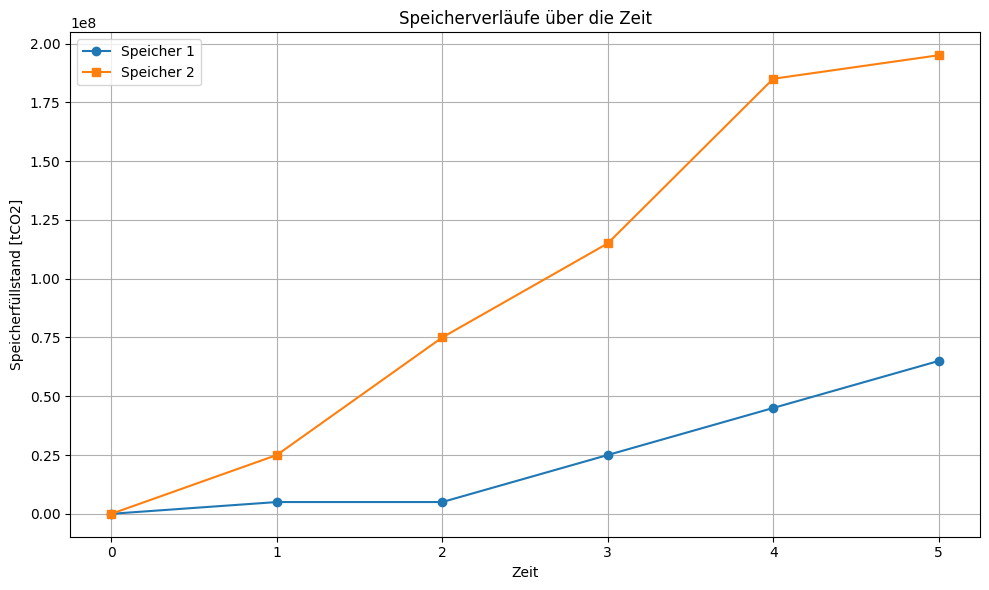

In [46]:
# Plot Speicherstände
plt.figure(figsize=(10, 6))
plt.plot(results_df['t'], results_df['soc1'], label='Speicher 1', marker='o')
plt.plot(results_df['t'], results_df['soc2'], label='Speicher 2', marker='s')
plt.xlabel('Zeit')
plt.ylabel('Speicherfüllstand [tCO2]')
plt.title('Speicherverläufe über die Zeit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()